#**Gastrointestinal Disease Mapping Using AI**
##**Objective 2: Image Classifier for KID Dataset (ResNet50)**
---
> <p align = "justify">This objective aims to apply the knoweledge gained from the previous objective to create an an image classifer for the KID dataset usign CNNs and some of the overfitting techniques covered 
---
 



In [27]:
import tensorflow as tf
import datetime, os, cv2, math, random, PIL, PIL.Image,pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from tqdm import tqdm
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorboard.plugins.hparams import api as hp
from tensorboard import notebook
from sklearn.metrics import plot_confusion_matrix, ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns

print("TensorFlow Version Used: ",tf.__version__)

TensorFlow Version Used:  2.9.2


#1- Loading the KID Dataset

In [2]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [3]:
DATADIR = '/content/gdrive/MyDrive/Colab_Notebooks/kid-dataset-2'
CATEGORIES = ['ampulla-of-vater', 'vascular','inflammatory', 'normal-colon',
              'normal-esophagus','normal-small-bowel', 'normal-stomach',
              'polypoids'] # 8 labels
data_dir = pathlib.Path(DATADIR)

#2- Checking Dataset was Loaded Correctly and Initial Class Distribution

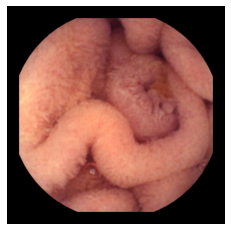

tf.Tensor([360 360   3], shape=(3,), dtype=int32)


In [4]:
for category in CATEGORIES:  
    path = os.path.join(DATADIR,category)  # create path 
    for img in os.listdir(path):  # iterate over each image per category
        image_array = mpimg.imread(os.path.join(path,img))
        plt.imshow(image_array)  # graph it
        plt.axis("off")
        plt.show()  # display!
        print(tf.shape(image_array))
        break  # we just want one for now so break
    break  

In [5]:
ampulla = list(data_dir.glob('ampulla-of-vater/*'))
print("ampulla picture number: ",len(ampulla))

inflammatory = list(data_dir.glob('inflammatory/*'))
print("inflammatory picture number: ",len(inflammatory))

colon = list(data_dir.glob('normal-colon/*'))
print("normal colon picture number: ",len(colon))

esophagus = list(data_dir.glob('normal-esophagus/*'))
print("normal esophagus picture number: ",len(esophagus))

smallbowel = list(data_dir.glob('normal-small-bowel/*'))
print("normal small bowel picture number: ",len(smallbowel))

stomach = list(data_dir.glob('normal-stomach/*'))
print("normal stomach picture number: ",len(stomach))

polypoids = list(data_dir.glob('polypoids/*'))
print("polypoids picture number: ",len(polypoids))

vascular = list(data_dir.glob('vascular/*'))
print("vascular picture number: ",len(vascular))

print("total picture number:", len(ampulla)+len(inflammatory)+len(colon)+len(esophagus)+len(smallbowel)+len(polypoids)+len(vascular)+len(stomach))

ampulla picture number:  19
inflammatory picture number:  227
normal colon picture number:  169
normal esophagus picture number:  282
normal small bowel picture number:  728
normal stomach picture number:  599
polypoids picture number:  44
vascular picture number:  303
total picture number: 2371


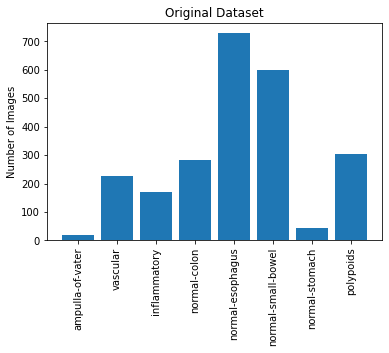

In [6]:
original_list = [len(ampulla),len(inflammatory),len(colon),len(esophagus),len(smallbowel),len(stomach),len(polypoids),len(vascular)]
plt.bar(CATEGORIES, original_list, align='center', alpha=1, label = 'Original Dataset')
plt.xticks(rotation='vertical')
plt.title('Original Dataset')
plt.ylabel('Number of Images')
plt.show()

#3- Splitting Dataset Into Traning and Testing Datasets

In [7]:
batch_size = 32
img_height = 360
img_width = 360

##3.1- Training Dataset

In [8]:
#Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
  DATADIR,
  labels = 'inferred',
  label_mode = 'int',
  validation_split=0.20, #set to 0.15 to get natural number for number of 
  #batches when counting training data
  subset="training",
  shuffle = True,
  seed= 123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(class_names)


Found 2371 files belonging to 8 classes.
Using 1897 files for training.
['ampulla-of-vater', 'inflammatory', 'normal-colon', 'normal-esophagus', 'normal-small-bowel', 'normal-stomach', 'polypoids', 'vascular']


##3.2-Training Dataset count

**Important note: <br>**
The 1st for loop refers to the amount of batches for a given dataset which in this case if the training dataset. There were 1897 images and each batch has 32 images, therefore: 1897/32 = 59.28 etc. As this is not a natural number it is not possible to go through every image in the training dataset. Even if a different training to validation ratio was selected for that to be the case it is not guaranteed that the number of batches would be a natural number as well. Thus, we accept that some images will be left behind, but the idea here was to get a sense of how proportional the training to validation per label was, and it seems to be reasonable. Additionally, if the number 60 is used instead of 59 then there would be excess of images counted which is perhaps worse than counting fewer images because having more images leads to better results, and consequently greater expectations. Thus, it is best to have a more “pessimistic” point of view than “optimistic”.

In [9]:
#Training Dataset count
ampulla_train_count,inflammatory_train_count,colon_train_count,esophagus_train_count, bowel_train_count, stomach_train_count, polypoids_train_count, vascular_train_count = 0,0,0,0,0,0,0,0

for f in range(59): #number of training files/batch size 
  for images, label in train_ds.take(1):
    for i in range(32):
      #print(class_names[label[i]])
      if class_names[label[i]] == class_names[0]:
        ampulla_train_count = 1 + ampulla_train_count

      elif class_names[label[i]] == class_names[1]:
        inflammatory_train_count = 1 + inflammatory_train_count

      elif class_names[label[i]] == class_names[2]:
        colon_train_count = 1 + colon_train_count

      elif class_names[label[i]] == class_names[3]:
        esophagus_train_count = 1 + esophagus_train_count

      elif class_names[label[i]] == class_names[4]:
        bowel_train_count = 1 + bowel_train_count   

      elif class_names[label[i]] == class_names[5]:
        stomach_train_count = 1 + stomach_train_count 

      elif class_names[label[i]] == class_names[6]:
        polypoids_train_count = 1 + polypoids_train_count

      elif class_names[label[i]] == class_names[7]:
        vascular_train_count = 1 + vascular_train_count

In [10]:
print("Ampulla Training Images: ", ampulla_train_count)      
print("Inflammatory Training Images: ", inflammatory_train_count)  
print("Normal Colon Training Images: ", colon_train_count)  
print("Normal Esophagus Training Images: ", esophagus_train_count)  
print("Normal Small Bowel Training Images: ", bowel_train_count)  
print("Normal Stomach Training Images: ", stomach_train_count)  
print("Polypoids Training Images: ", polypoids_train_count) 
print("Vascular Training Images: ", vascular_train_count)
print("Total Training Images Couned:", ampulla_train_count+inflammatory_train_count+colon_train_count+ esophagus_train_count+stomach_train_count+bowel_train_count+polypoids_train_count+vascular_train_count)

Ampulla Training Images:  8
Inflammatory Training Images:  122
Normal Colon Training Images:  125
Normal Esophagus Training Images:  237
Normal Small Bowel Training Images:  588
Normal Stomach Training Images:  554
Polypoids Training Images:  25
Vascular Training Images:  229
Total Training Images Couned: 1888


##3.3- Training Dataset Example Image Display

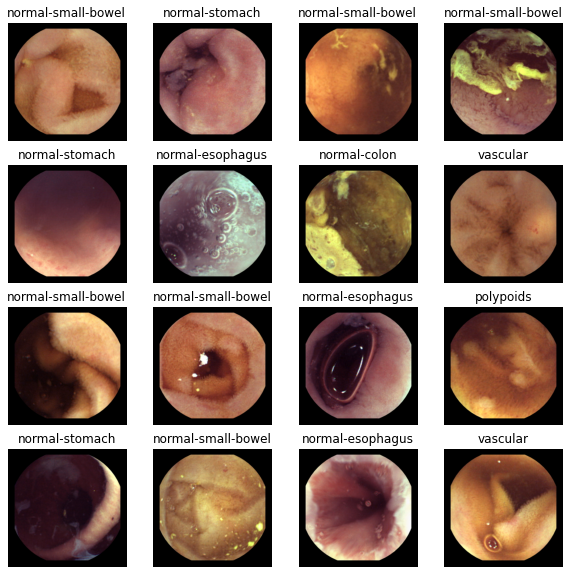

In [11]:
plt.figure(figsize=(10, 10))
for images, label in train_ds.take(1):
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[label[i]])
    plt.axis("off")


##3.4-Validation Dataset

In [12]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  DATADIR,
  labels = 'inferred',
  label_mode = 'int',
  validation_split=0.20,
  subset="validation",
  shuffle = True,
  seed= 123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 2371 files belonging to 8 classes.
Using 474 files for validation.


##3.5- Validation Dataset Count

In [13]:
ampulla_val_count,inflammatory_val_count,colon_val_count,esophagus_val_count, bowel_val_count, stomach_val_count, polypoids_val_count, vascular_val_count = 0,0,0,0,0,0,0,0

for f in range(14): #number of training files/batch size 
  for images, label in train_ds.take(1):
    for i in range(32): #batch size
      
      if class_names[label[i]] == class_names[0]:
        ampulla_val_count = 1 + ampulla_val_count

      elif class_names[label[i]] == class_names[1]:
        inflammatory_val_count = 1 + inflammatory_val_count

      elif class_names[label[i]] == class_names[2]:
        colon_val_count = 1 + colon_val_count

      elif class_names[label[i]] == class_names[3]:
        esophagus_val_count = 1 + esophagus_val_count

      elif class_names[label[i]] == class_names[4]:
        bowel_val_count = 1 + bowel_val_count   

      elif class_names[label[i]] == class_names[5]:
        stomach_val_count = 1 + stomach_val_count 

      elif class_names[label[i]] == class_names[6]:
        polypoids_val_count = 1 + polypoids_val_count

      elif class_names[label[i]] == class_names[7]:
        vascular_val_count = 1 + vascular_val_count

In [14]:
print("Ampulla Validation Images: ", ampulla_val_count)      
print("Inflammatory Validation Images: ", inflammatory_val_count)  
print("Normal Colon Validation Images: ", colon_val_count)  
print("Normal Esophagus Validation Images: ", esophagus_val_count)  
print("Normal Small Bowel Validation Images: ", bowel_val_count)  
print("Normal Stomach Validation Images: ", stomach_val_count)  
print("Polypoids Validation Images: ", polypoids_val_count) 
print("Vascular Validation Images: ", vascular_val_count)
print("Total Validation Images Couned:", ampulla_val_count+inflammatory_val_count+colon_val_count+ esophagus_val_count+bowel_val_count+stomach_val_count+polypoids_val_count+vascular_val_count)

Ampulla Validation Images:  5
Inflammatory Validation Images:  37
Normal Colon Validation Images:  19
Normal Esophagus Validation Images:  65
Normal Small Bowel Validation Images:  125
Normal Stomach Validation Images:  133
Polypoids Validation Images:  11
Vascular Validation Images:  53
Total Validation Images Couned: 448


##3.6-Validation Dataset Example Image Display

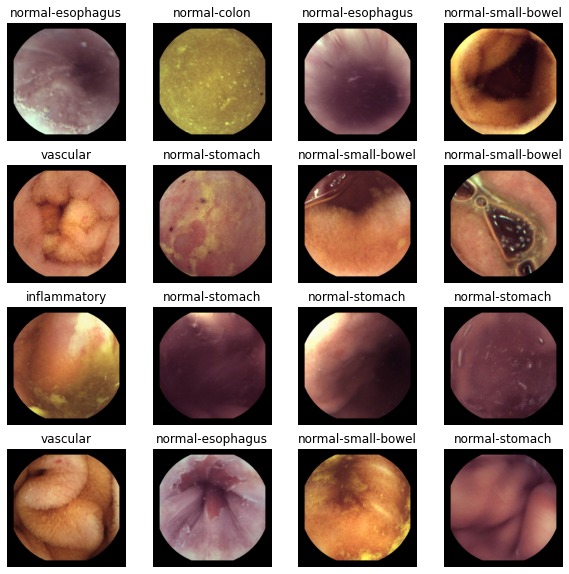

In [15]:
plt.figure(figsize=(10, 10))
for images, labels in val_ds.take(1):
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

##3.7- Final Training and Validation Proportion Check (Bar Chart)

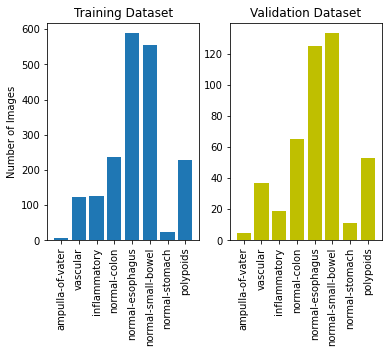

In [16]:
training_list = [ampulla_train_count,inflammatory_train_count,colon_train_count,esophagus_train_count, bowel_train_count, stomach_train_count, polypoids_train_count, vascular_train_count]
validation_list = [ampulla_val_count,inflammatory_val_count,colon_val_count,esophagus_val_count, bowel_val_count, stomach_val_count, polypoids_val_count, vascular_val_count]
plt.subplot(1, 2, 1)
plt.bar(CATEGORIES, training_list, align='center', alpha=1, label = 'Training Dataset')
plt.xticks(rotation='vertical')
plt.title('Training Dataset')
plt.ylabel('Number of Images')
plt.subplot(1,2,2)
plt.bar(CATEGORIES, validation_list, color='y',label = 'Validation Dataset')
plt.xticks(rotation='vertical')
plt.title('Validation Dataset')
plt.show()

#4- Creating a Model 

##4.1- Standardizing the Data and Performance Configuration

In [17]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

normalization_layer = layers.Rescaling(1./255)

normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

(32, 360, 360, 3)
(32,)
0.0 1.0


In [18]:
class_weight = {0: 728/19,
                1: 728/303,
                2: 728/227,
                3: 728/169,
                4: 728/282,
                5: 1,
                6: 728/599,
                7: 728/44}
print(class_weight)

{0: 38.31578947368421, 1: 2.402640264026403, 2: 3.20704845814978, 3: 4.3076923076923075, 4: 2.5815602836879434, 5: 1, 6: 1.2153589315525877, 7: 16.545454545454547}


##4.2- CNN Model

In [19]:
#Clear the CNNs weigths each time to prevent training on a net with weigths from 
#previous tests

tf.keras.backend.clear_session()

demo_inception_model7 = tf.keras.Sequential()

pretrained_model_for_demo7= tf.keras.applications.inception_v3.InceptionV3(include_top=False,input_shape=(360,360,3),pooling='avg',weights='imagenet',classes=8)

for each_layer in pretrained_model_for_demo7.layers:
  each_layer.trainable=False

demo_inception_model7.add(pretrained_model_for_demo7)
#tf.keras.utils.plot_model(pretrained_model_for_demo, show_shapes=True)
demo_inception_model7.add(Flatten())

demo_inception_model7.add(Dense(250, activation='relu'))

demo_inception_model7.add(Dense(8, activation='softmax'))

87910968/87910968 [==============================] - 1s 0us/step


In [20]:
demo_inception_model7.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

##4.3- Model Training 

In [21]:
history_inception7= demo_inception_model7.fit(train_ds,
                    validation_data=val_ds,
                    epochs=20,
                    batch_size = 32,
                    class_weight = class_weight)


Epoch 1/20


/usr/local/lib/python3.8/dist-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


60/60 [==============================] - 21s 146ms/step - loss: 55.0243 - accuracy: 0.2151 - val_loss: 6.1895 - val_accuracy: 0.1582
Epoch 2/20
60/60 [==============================] - 3s 47ms/step - loss: 18.6331 - accuracy: 0.1682 - val_loss: 5.6696 - val_accuracy: 0.1456
Epoch 3/20
60/60 [==============================] - 3s 48ms/step - loss: 16.1847 - accuracy: 0.1729 - val_loss: 5.0113 - val_accuracy: 0.1688
Epoch 4/20
60/60 [==============================] - 3s 47ms/step - loss: 14.4453 - accuracy: 0.1908 - val_loss: 4.6008 - val_accuracy: 0.1772
Epoch 5/20
60/60 [==============================] - 3s 47ms/step - loss: 13.5033 - accuracy: 0.2008 - val_loss: 4.6050 - val_accuracy: 0.1730
Epoch 6/20
60/60 [==============================] - 3s 47ms/step - loss: 12.4866 - accuracy: 0.2119 - val_loss: 4.0061 - val_accuracy: 0.1983
Epoch 7/20
60/60 [==============================] - 3s 47ms/step - loss: 11.8527 - accuracy: 0.2103 - val_loss: 4.1827 - val_accuracy: 0.2110
Epoch 8/20
60/6

#5- Evaluating The Model

##5.1- Performance Assessment

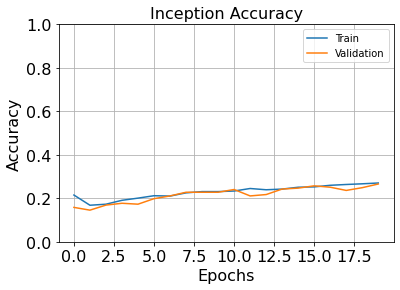

In [22]:
#accuracy plot
plt.plot(history_inception7.history['accuracy'])
plt.plot(history_inception7.history['val_accuracy'])
plt.axis(ymin=0,ymax=1)
plt.grid()
plt.title('Inception Accuracy',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.legend(['Train', 'Validation'])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

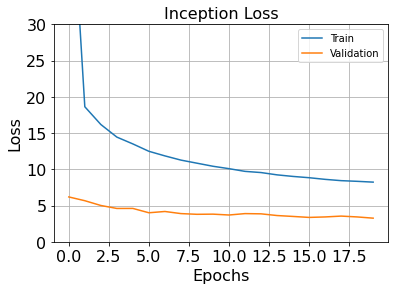

In [23]:
#loss plot
plt.plot(history_inception7.history['loss'])
plt.plot(history_inception7.history['val_loss'])
plt.axis(ymin=0,ymax=30)
plt.grid()
plt.title('Inception Loss',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.legend(['Train', 'Validation'])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

##5.2- Table Values and Other Metrics

In [25]:
from IPython.core.display import display_pdf

loss = history_inception7.history['loss']
val_loss = history_inception7.history['val_loss']
accuracy = history_inception7.history['accuracy']
val_accuracy = history_inception7.history['val_accuracy']
df = pd.DataFrame({'Loss':loss,
                   'Accuracy': accuracy,
                   'Validation Loss':val_loss,
                   'Validation Accuracy': val_accuracy})
#Print the DataFrame
display(df)

,Loss,Accuracy,Validation Loss,Validation Accuracy
0,55.024250,0.215076,6.189480,0.158228
1,18.633051,0.168160,5.669647,0.145570
2,16.184666,0.172905,5.011278,0.168776
3,14.445303,0.190828,4.600770,0.177215
4,13.503316,0.200843,4.604956,0.172996
5,12.486576,0.211914,4.006076,0.198312
6,11.852708,0.210332,4.182694,0.210970
7,11.271630,0.225092,3.891190,0.227848
8,10.846103,0.230891,3.792943,0.227848
9,10.421663,0.230891,3.814328,0.227848


##5.3- Confusion Matrix

15/15 [==============================] - 1s 37ms/step


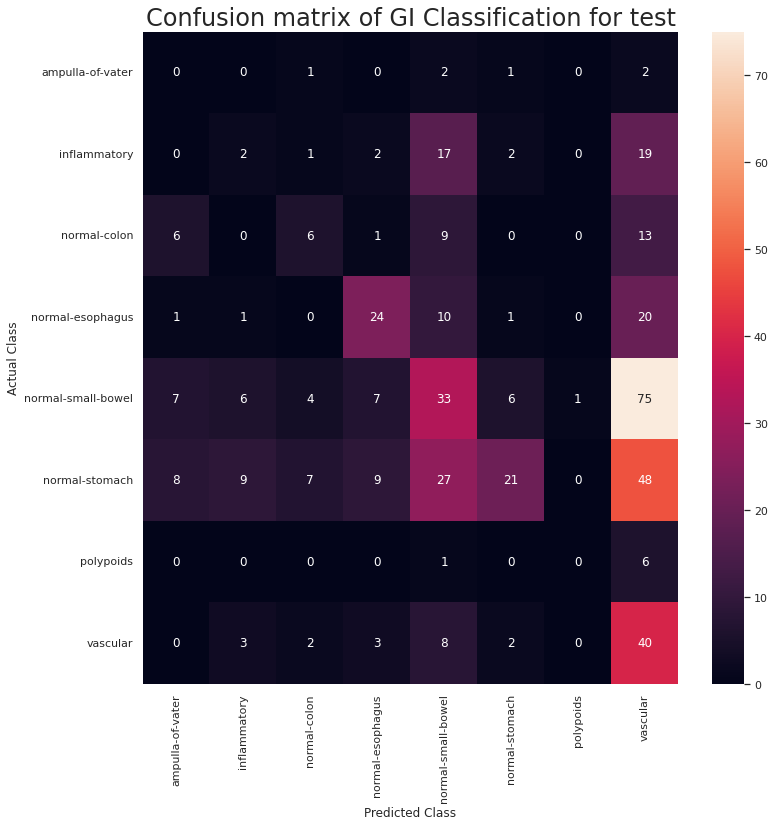

In [33]:
def get_actual_predicted_labels(dataset): 
  """
    Create a list of actual ground truth values and the predictions from the model.

    Args:
      dataset: An iterable data structure, such as a TensorFlow Dataset, with features and labels.

    Return:
      Ground truth and predicted values for a particular dataset.
  """
  actual = [labels for _, labels in dataset.unbatch()]
  predicted = demo_inception_model7.predict(dataset)

  actual = tf.stack(actual, axis=0)
  predicted = tf.concat(predicted, axis=0)
  predicted = tf.argmax(predicted, axis=1)

  return actual, predicted

  import seaborn as sns
def plot_confusion_matrix(actual, predicted, labels, ds_type):
  cm = tf.math.confusion_matrix(actual, predicted)
  ax = sns.heatmap(cm, annot=True, fmt='g')
  sns.set(rc={'figure.figsize':(12, 12)})
  sns.set(font_scale=2.0)
  ax.set_title('Confusion matrix of GI Classification for ' + ds_type)
  ax.set_xlabel('Predicted Class')
  ax.set_ylabel('Actual Class')
  plt.xticks(rotation=90)
  plt.yticks(rotation=0)
  ax.xaxis.set_ticklabels(labels)
  ax.yaxis.set_ticklabels(labels)


labels = list(class_names)

actual, predicted = get_actual_predicted_labels(val_ds)
plot_confusion_matrix(actual, predicted, labels, 'test')

60/60 [==============================] - 2s 35ms/step


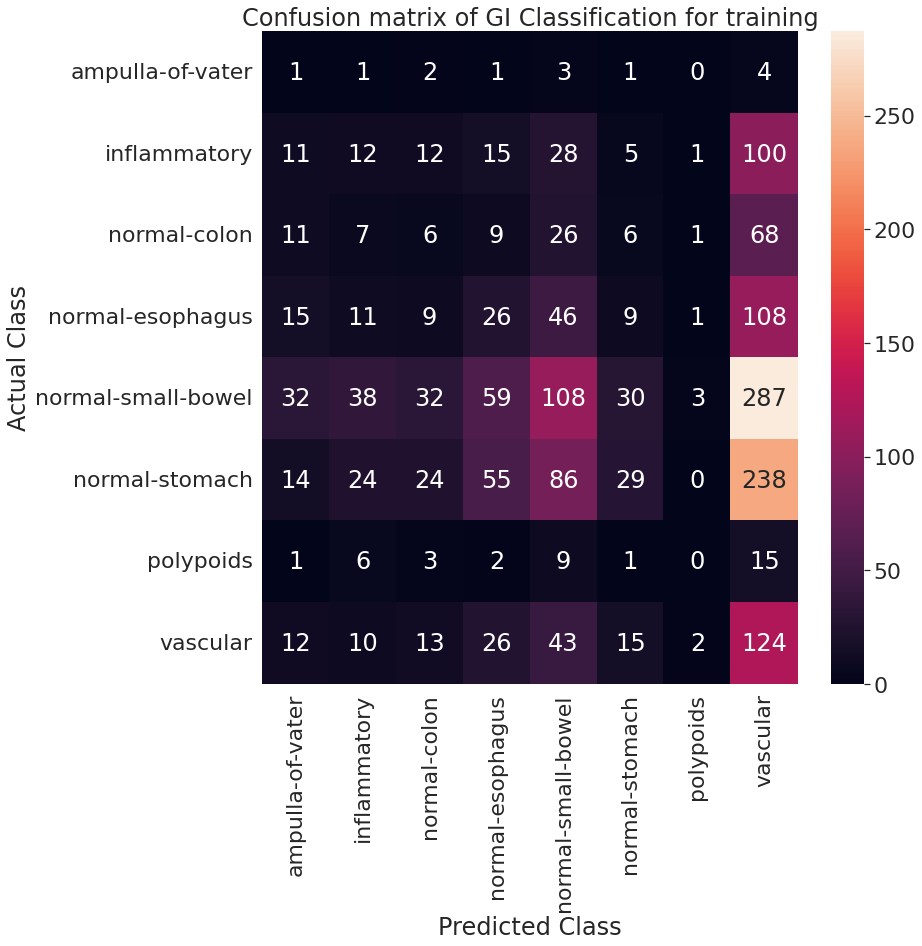

In [34]:
actual, predicted = get_actual_predicted_labels(train_ds)
plot_confusion_matrix(actual, predicted, labels, 'training')